# Mô phỏng thuật toán tìm đường × hành vi Ghost

> **Môn học:** Nhập môn Trí tuệ nhân tạo — Đại học Bách Khoa Hà Nội

Notebook này **mô phỏng trực quan** cách Ghost di chuyển trong maze với:
- **4 thuật toán tìm đường**: BFS, A*, GBFS, Dijkstra
- **5 hành vi**: Chase, Predict, Flank, Patrol, Random
- **Tạo mê cung**: DFS (Randomized Depth-First Search)

Tất cả các mô phỏng sử dụng **cùng một mê cung** (seed=42) để dễ dàng so sánh sự khác biệt.

Mỗi mô phỏng hiển thị:
- 🟡 Pacman (mục tiêu)
- 👻 Ghost (điểm xuất phát)
- 🔵 Đường đi Ghost tìm được
- 🟢 Các ô đã duyệt (explored nodes)

In [36]:
import time
import heapq
import random
from collections import deque

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.colors import to_rgba
import numpy as np
from IPython.display import display, HTML

%matplotlib inline
plt.rcParams['figure.dpi'] = 100

## 1. Tạo Maze (DFS) và các hàm hỗ trợ

Mê cung được tạo bằng thuật toán **DFS** (Randomized Depth-First Search / Recursive Backtracking), sau đó phá thêm 15% tường để tạo nhiều đường đi.

In [37]:
class SimpleCell:
    def __init__(self, x, y):
        self.x = x
        self.y = y
        self.col = x
        self.row = y
        self.walls = {"top": True, "bottom": True, "left": True, "right": True}
        self.generated = False

def create_grid(cols, rows):
    return [SimpleCell(col, row) for row in range(rows) for col in range(cols)]

def get_cell(grid, x, y, cols, rows):
    if 0 <= x < cols and 0 <= y < rows:
        return grid[y * cols + x]
    return None

def generate_maze_dfs(grid, cols, rows):
    start_cell = grid[0]
    start_cell.generated = True
    stack = [start_cell]
    while stack:
        current = stack[-1]
        x, y = current.col, current.row
        directions = [(0,-1,"top","bottom"), (0,1,"bottom","top"),
                      (-1,0,"left","right"), (1,0,"right","left")]
        neighbors = []
        for dx, dy, w1, w2 in directions:
            n = get_cell(grid, x+dx, y+dy, cols, rows)
            if n and not n.generated:
                neighbors.append((n, w1, w2))
        if neighbors:
            neighbor, w1, w2 = random.choice(neighbors)
            current.walls[w1] = False
            neighbor.walls[w2] = False
            neighbor.generated = True
            stack.append(neighbor)
        else:
            stack.pop()

def add_extra_paths(grid, cols, rows, ratio=0.15):
    removable = []
    for cell in grid:
        x, y = cell.col, cell.row
        if x < cols-1 and cell.walls["right"]:
            r = get_cell(grid, x+1, y, cols, rows)
            if r: removable.append((cell, r, "right", "left"))
        if y < rows-1 and cell.walls["bottom"]:
            b = get_cell(grid, x, y+1, cols, rows)
            if b: removable.append((cell, b, "bottom", "top"))
    num = int(len(removable) * ratio)
    for c1, c2, w1, w2 in random.sample(removable, min(num, len(removable))):
        c1.walls[w1] = False
        c2.walls[w2] = False

def create_maze(cols, rows, seed=42):
    random.seed(seed)
    grid = create_grid(cols, rows)
    generate_maze_dfs(grid, cols, rows)
    add_extra_paths(grid, cols, rows, 0.15)
    return grid

def get_neighbors(grid, cx, cy, cols, rows):
    idx = cx + cy * cols
    cell = grid[idx]
    result = []
    for dx, dy, wall in [(0,-1,"top"), (0,1,"bottom"), (-1,0,"left"), (1,0,"right")]:
        nx, ny = cx+dx, cy+dy
        if 0 <= nx < cols and 0 <= ny < rows and not cell.walls[wall]:
            result.append((nx, ny))
    return result

def heuristic(a, b):
    return abs(a[0]-b[0]) + abs(a[1]-b[1])

print("✓ Maze functions ready.")

✓ Maze functions ready.


## 2. Cài đặt 4 thuật toán tìm đường (trả về cả path + explored nodes)

- **BFS**: Duyệt theo chiều rộng — tìm đường ngắn nhất
- **A***: g(n) + h(n) — hiệu quả nhất nhờ heuristic
- **GBFS**: Chỉ dùng h(n) — nhanh nhưng không tối ưu
- **Dijkstra**: Chi phí tăng dần — tìm đường ngắn nhất, không heuristic

In [38]:
def bfs_search(grid, cols, rows, start, goal):
    """BFS: duyệt theo chiều rộng."""
    queue = deque([(start, [start])])
    visited = {start}
    explored_order = []
    while queue:
        (cx, cy), path = queue.popleft()
        explored_order.append((cx, cy))
        if (cx, cy) == goal:
            return path, explored_order
        for nx, ny in get_neighbors(grid, cx, cy, cols, rows):
            if (nx, ny) not in visited:
                visited.add((nx, ny))
                queue.append(((nx, ny), path + [(nx, ny)]))
    return None, explored_order

def astar_search(grid, cols, rows, start, goal):
    """A*: g(n) + h(n)."""
    counter = 0
    open_set = [(heuristic(start, goal), 0, counter, start, [start])]
    visited = set()
    explored_order = []
    while open_set:
        f, g, _, (cx, cy), path = heapq.heappop(open_set)
        if (cx, cy) in visited: continue
        visited.add((cx, cy))
        explored_order.append((cx, cy))
        if (cx, cy) == goal:
            return path, explored_order
        for nx, ny in get_neighbors(grid, cx, cy, cols, rows):
            if (nx, ny) not in visited:
                counter += 1
                new_g = g + 1
                heapq.heappush(open_set, (new_g + heuristic((nx,ny), goal), new_g, counter, (nx,ny), path+[(nx,ny)]))
    return None, explored_order

def gbfs_search(grid, cols, rows, start, goal):
    """GBFS: chỉ dùng heuristic h(n)."""
    counter = 0
    open_set = [(heuristic(start, goal), counter, start, [start])]
    visited = set()
    explored_order = []
    while open_set:
        h, _, (cx, cy), path = heapq.heappop(open_set)
        if (cx, cy) in visited: continue
        visited.add((cx, cy))
        explored_order.append((cx, cy))
        if (cx, cy) == goal:
            return path, explored_order
        for nx, ny in get_neighbors(grid, cx, cy, cols, rows):
            if (nx, ny) not in visited:
                counter += 1
                heapq.heappush(open_set, (heuristic((nx,ny), goal), counter, (nx,ny), path+[(nx,ny)]))
    return None, explored_order

def dijkstra_search(grid, cols, rows, start, goal):
    """Dijkstra: uniform cost (không heuristic)."""
    counter = 0
    open_set = [(0, counter, start, [start])]
    visited = set()
    explored_order = []
    while open_set:
        cost, _, (cx, cy), path = heapq.heappop(open_set)
        if (cx, cy) in visited: continue
        visited.add((cx, cy))
        explored_order.append((cx, cy))
        if (cx, cy) == goal:
            return path, explored_order
        for nx, ny in get_neighbors(grid, cx, cy, cols, rows):
            if (nx, ny) not in visited:
                counter += 1
                heapq.heappush(open_set, (cost+1, counter, (nx,ny), path+[(nx,ny)]))
    return None, explored_order

ALGORITHMS = {
    "BFS": bfs_search,
    "A*": astar_search,
    "GBFS": gbfs_search,
    "Dijkstra": dijkstra_search,
}
print(f"✓ {len(ALGORITHMS)} thuật toán tìm đường: {list(ALGORITHMS.keys())}")
print("  (DFS được dùng để tạo mê cung, không phải tìm đường)")

✓ 4 thuật toán tìm đường: ['BFS', 'A*', 'GBFS', 'Dijkstra']
  (DFS được dùng để tạo mê cung, không phải tìm đường)


## 3. Hàm vẽ mô phỏng maze

Hiển thị: tường maze, các ô đã duyệt (explored), đường đi tìm được (path), vị trí Ghost và Pacman.

In [39]:
ALGO_COLORS = {
    "BFS": "#2196F3", "A*": "#4CAF50",
    "GBFS": "#9C27B0", "Dijkstra": "#FF9800",
}

def draw_maze_sim(ax, grid, cols, rows, explored, path, ghost_pos, target_pos,
                  algo_name, behavior_name, color):
    """Vẽ 1 ô mô phỏng: maze + explored + path + ghost + target."""
    ax.set_xlim(-0.5, cols - 0.5)
    ax.set_ylim(rows - 0.5, -0.5)
    ax.set_aspect("equal")
    ax.set_facecolor("#111122")
    ax.set_xticks([])
    ax.set_yticks([])

    # Vẽ explored nodes (ô đã duyệt)
    for i, (ex, ey) in enumerate(explored):
        alpha = 0.15 + 0.35 * (i / max(len(explored), 1))
        rect = plt.Rectangle((ex-0.45, ey-0.45), 0.9, 0.9,
                              facecolor=(*to_rgba(color)[:3], min(alpha, 0.5)),
                              edgecolor="none")
        ax.add_patch(rect)

    # Vẽ tường
    for cell in grid:
        x, y = cell.col, cell.row
        lw = 1.5
        wc = "#3355CC"
        if cell.walls["top"]:
            ax.plot([x-0.5, x+0.5], [y-0.5, y-0.5], color=wc, linewidth=lw)
        if cell.walls["bottom"]:
            ax.plot([x-0.5, x+0.5], [y+0.5, y+0.5], color=wc, linewidth=lw)
        if cell.walls["left"]:
            ax.plot([x-0.5, x-0.5], [y-0.5, y+0.5], color=wc, linewidth=lw)
        if cell.walls["right"]:
            ax.plot([x+0.5, x+0.5], [y-0.5, y+0.5], color=wc, linewidth=lw)

    # Vẽ đường đi
    if path and len(path) > 1:
        px = [p[0] for p in path]
        py = [p[1] for p in path]
        ax.plot(px, py, color=color, linewidth=3, alpha=0.9, zorder=5)
        # Mũi tên chỉ hướng di chuyển
        for i in range(0, len(path)-1, max(1, len(path)//6)):
            dx = path[i+1][0] - path[i][0]
            dy = path[i+1][1] - path[i][1]
            ax.annotate("", xy=(path[i+1][0], path[i+1][1]),
                       xytext=(path[i][0], path[i][1]),
                       arrowprops=dict(arrowstyle="->", color=color, lw=1.5),
                       zorder=6)

    # Ghost (điểm xuất phát)
    gx, gy = ghost_pos
    ghost_circle = plt.Circle((gx, gy), 0.35, facecolor="#FF0000", edgecolor="white", linewidth=2, zorder=10)
    ax.add_patch(ghost_circle)
    ax.text(gx, gy, "👻", ha="center", va="center", fontsize=8, zorder=11)

    # Target (Pacman / mục tiêu)
    tx, ty = target_pos
    target_circle = plt.Circle((tx, ty), 0.35, facecolor="#FFFF00", edgecolor="white", linewidth=2, zorder=10)
    ax.add_patch(target_circle)
    ax.text(tx, ty, "🟡", ha="center", va="center", fontsize=8, zorder=11)

    # Title
    path_len = len(path) if path else 0
    ax.set_title(f"{algo_name}\n{behavior_name}\n"
                 f"Path: {path_len} | Explored: {len(explored)}",
                 fontsize=9, fontweight="bold", color="white",
                 bbox=dict(boxstyle="round,pad=0.3", facecolor="#222244", edgecolor=color, linewidth=2))

print("✓ Drawing functions ready.")

✓ Drawing functions ready.


## 4. Hệ thống hành vi Ghost

Mô phỏng cách mỗi hành vi tính toán **mục tiêu (target)** khác nhau:
- **Chase**: Đuổi thẳng đến Pacman
- **Predict**: Nhắm 3 ô phía trước Pacman
- **Flank**: Đi vòng phía sau Pacman
- **Patrol**: Tuần tra 4 góc bản đồ
- **Random**: Chọn 1 ô ngẫu nhiên

In [40]:
def get_behavior_target(behavior, ghost_pos, pacman_pos, pacman_dir, cols, rows):
    """Tính mục tiêu dựa trên hành vi Ghost."""
    px, py = pacman_pos

    if behavior == "chase":
        return px, py

    elif behavior == "predict":
        ahead = 3
        tx, ty = px, py
        if pacman_dir == "up":    ty = max(0, py - ahead)
        elif pacman_dir == "down":  ty = min(rows-1, py + ahead)
        elif pacman_dir == "left":  tx = max(0, px - ahead)
        elif pacman_dir == "right": tx = min(cols-1, px + ahead)
        return tx, ty

    elif behavior == "flank":
        flank_dist = 3
        tx, ty = px, py
        if pacman_dir == "up":    ty = min(rows-1, py + flank_dist)
        elif pacman_dir == "down":  ty = max(0, py - flank_dist)
        elif pacman_dir == "left":  tx = min(cols-1, px + flank_dist)
        elif pacman_dir == "right": tx = max(0, px - flank_dist)
        return tx, ty

    elif behavior == "patrol":
        corners = [(1,1), (cols-2, 1), (cols-2, rows-2), (1, rows-2)]
        # Chọn góc gần nhất mà ghost chưa ở
        gx, gy = ghost_pos
        best = min(corners, key=lambda c: abs(c[0]-gx) + abs(c[1]-gy))
        if abs(best[0]-gx) + abs(best[1]-gy) <= 1:
            idx = (corners.index(best) + 1) % 4
            best = corners[idx]
        return best

    elif behavior == "random":
        return random.randint(0, cols-1), random.randint(0, rows-1)

    return px, py

BEHAVIORS = {
    "Chase":   ("chase",   "Đuổi thẳng đến Pacman"),
    "Predict": ("predict", "Nhắm 3 ô trước mặt Pacman"),
    "Flank":   ("flank",   "Đi vòng phía sau Pacman"),
    "Patrol":  ("patrol",  "Tuần tra các góc bản đồ"),
    "Random":  ("random",  "Chọn mục tiêu ngẫu nhiên"),
}

print("✓ Behaviors ready:", list(BEHAVIORS.keys()))

✓ Behaviors ready: ['Chase', 'Predict', 'Flank', 'Patrol', 'Random']


## 5. So sánh 4 thuật toán — Hành vi CHASE

Ghost ở góc trên-phải, Pacman ở giữa-trái. Cùng 1 mê cung (seed=42), mỗi thuật toán tìm đường khác nhau → số ô duyệt và đường đi khác nhau.

C:\Users\Admin\AppData\Local\Temp\ipykernel_6484\1722828775.py:20: UserWarning: Glyph 128123 (\N{GHOST}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\Admin\AppData\Local\Temp\ipykernel_6484\1722828775.py:20: UserWarning: Glyph 128993 (\N{LARGE YELLOW CIRCLE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\Admin\AppData\Local\Temp\ipykernel_6484\1722828775.py:20: UserWarning: Glyph 128269 (\N{LEFT-POINTING MAGNIFYING GLASS}) missing from font(s) DejaVu Sans.
  plt.tight_layout()


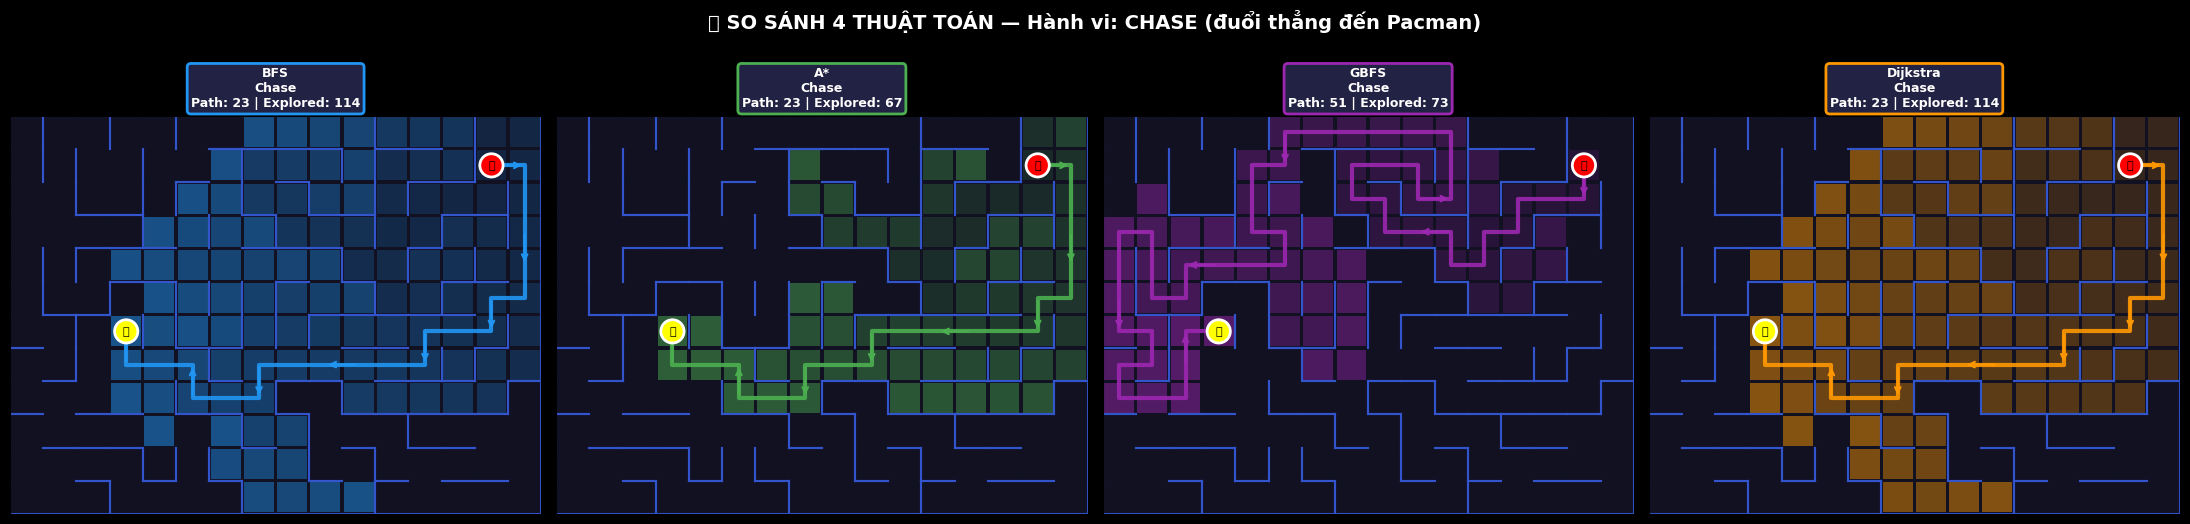


📊 BFS/A*/Dijkstra → đường ngắn nhất | GBFS → nhanh nhưng có thể đi vòng


In [41]:
# Tạo maze (DFS generation)
COLS, ROWS = 16, 12
grid = create_maze(COLS, ROWS, seed=42)

ghost_pos = (COLS-2, 1)
pacman_pos = (3, ROWS//2)
pacman_dir = "right"

fig, axes = plt.subplots(1, 4, figsize=(22, 5.5), facecolor="#000000")
fig.suptitle("🔍 SO SÁNH 4 THUẬT TOÁN — Hành vi: CHASE (đuổi thẳng đến Pacman)",
             fontsize=14, fontweight="bold", color="white", y=1.02)

for ax, (algo_name, algo_func) in zip(axes, ALGORITHMS.items()):
    target = get_behavior_target("chase", ghost_pos, pacman_pos, pacman_dir, COLS, ROWS)
    path, explored = algo_func(grid, COLS, ROWS, ghost_pos, target)
    color = ALGO_COLORS[algo_name]
    draw_maze_sim(ax, grid, COLS, ROWS, explored, path, ghost_pos, target,
                  algo_name, "Chase", color)

plt.tight_layout()
plt.show()
print("\n📊 BFS/A*/Dijkstra → đường ngắn nhất | GBFS → nhanh nhưng có thể đi vòng")

## 6. So sánh 4 thuật toán — Hành vi PREDICT

Mục tiêu (🟡) là **3 ô phía trước** Pacman theo hướng đang đi. Ghost cố chặn đầu Pacman.

C:\Users\Admin\AppData\Local\Temp\ipykernel_6484\968971239.py:12: UserWarning: Glyph 128123 (\N{GHOST}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\Admin\AppData\Local\Temp\ipykernel_6484\968971239.py:12: UserWarning: Glyph 128993 (\N{LARGE YELLOW CIRCLE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\Admin\AppData\Local\Temp\ipykernel_6484\968971239.py:12: UserWarning: Glyph 127919 (\N{DIRECT HIT}) missing from font(s) DejaVu Sans.
  plt.tight_layout()


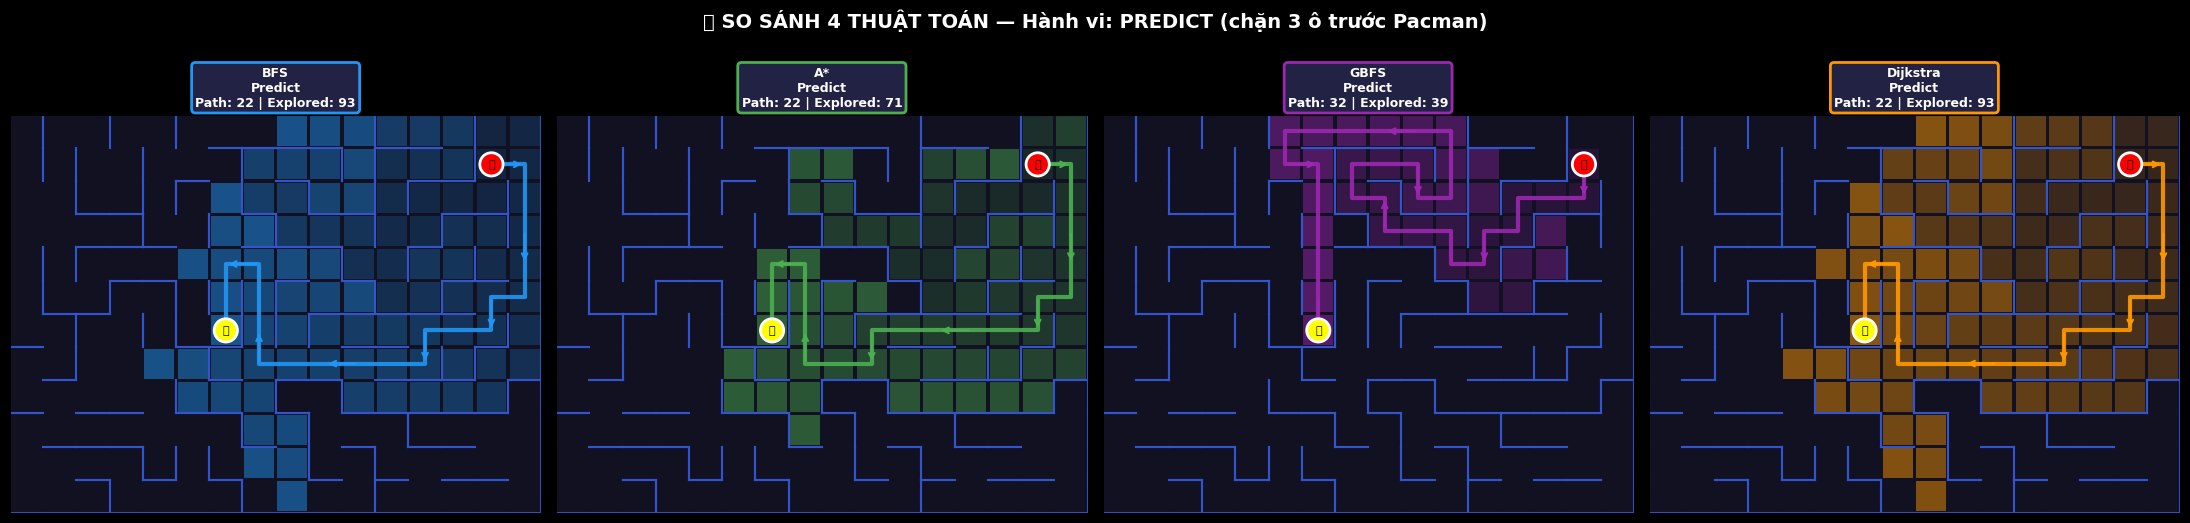


📊 Target (🟡) dịch về bên phải 3 ô — Ghost cố chặn đầu Pacman trước khi nó tới


In [50]:
fig, axes = plt.subplots(1, 4, figsize=(22, 5.5), facecolor="#000000")
fig.suptitle("🎯 SO SÁNH 4 THUẬT TOÁN — Hành vi: PREDICT (chặn 3 ô trước Pacman)",
             fontsize=14, fontweight="bold", color="white", y=1.02)

for ax, (algo_name, algo_func) in zip(axes, ALGORITHMS.items()):
    target = get_behavior_target("predict", ghost_pos, pacman_pos, pacman_dir, COLS, ROWS)
    path, explored = algo_func(grid, COLS, ROWS, ghost_pos, target)
    color = ALGO_COLORS[algo_name]
    draw_maze_sim(ax, grid, COLS, ROWS, explored, path, ghost_pos, target,
                  algo_name, "Predict", color)

plt.tight_layout()
plt.show()
print("\n📊 Target (🟡) dịch về bên phải 3 ô — Ghost cố chặn đầu Pacman trước khi nó tới")

## 7. So sánh 4 thuật toán — Hành vi FLANK

Mục tiêu (🟡) là **3 ô phía sau** Pacman. Ghost vòng phía sau để đánh lén từ phía Pacman không nhìn thấy.

C:\Users\Admin\AppData\Local\Temp\ipykernel_6484\4110006843.py:12: UserWarning: Glyph 128123 (\N{GHOST}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\Admin\AppData\Local\Temp\ipykernel_6484\4110006843.py:12: UserWarning: Glyph 128993 (\N{LARGE YELLOW CIRCLE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()


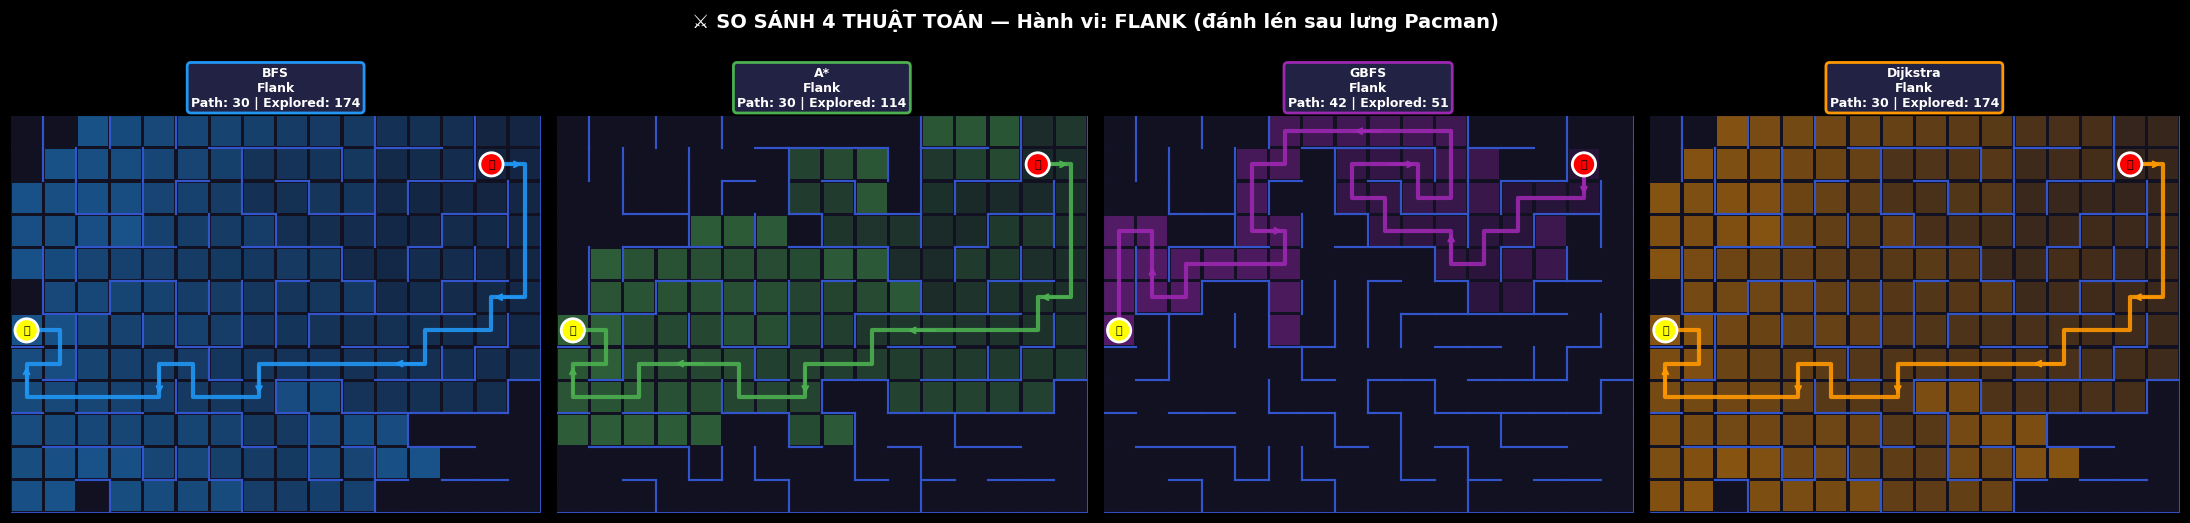


📊 Target (🟡) dịch ngược hướng Pacman — Ghost vòng ra sau tạo thế gọng kìm


In [51]:
fig, axes = plt.subplots(1, 4, figsize=(22, 5.5), facecolor="#000000")
fig.suptitle("⚔️ SO SÁNH 4 THUẬT TOÁN — Hành vi: FLANK (đánh lén sau lưng Pacman)",
             fontsize=14, fontweight="bold", color="white", y=1.02)

for ax, (algo_name, algo_func) in zip(axes, ALGORITHMS.items()):
    target = get_behavior_target("flank", ghost_pos, pacman_pos, pacman_dir, COLS, ROWS)
    path, explored = algo_func(grid, COLS, ROWS, ghost_pos, target)
    color = ALGO_COLORS[algo_name]
    draw_maze_sim(ax, grid, COLS, ROWS, explored, path, ghost_pos, target,
                  algo_name, "Flank", color)

plt.tight_layout()
plt.show()
print("\n📊 Target (🟡) dịch ngược hướng Pacman — Ghost vòng ra sau tạo thế gọng kìm")

## 8. So sánh 4 thuật toán — Hành vi PATROL

Mục tiêu (🟡) là **góc gần nhất** trên bản đồ. Ghost không quan tâm Pacman, chỉ tuần tra 4 góc.

C:\Users\Admin\AppData\Local\Temp\ipykernel_6484\3810394312.py:12: UserWarning: Glyph 128123 (\N{GHOST}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\Admin\AppData\Local\Temp\ipykernel_6484\3810394312.py:12: UserWarning: Glyph 128993 (\N{LARGE YELLOW CIRCLE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\Admin\AppData\Local\Temp\ipykernel_6484\3810394312.py:12: UserWarning: Glyph 128680 (\N{POLICE CARS REVOLVING LIGHT}) missing from font(s) DejaVu Sans.
  plt.tight_layout()


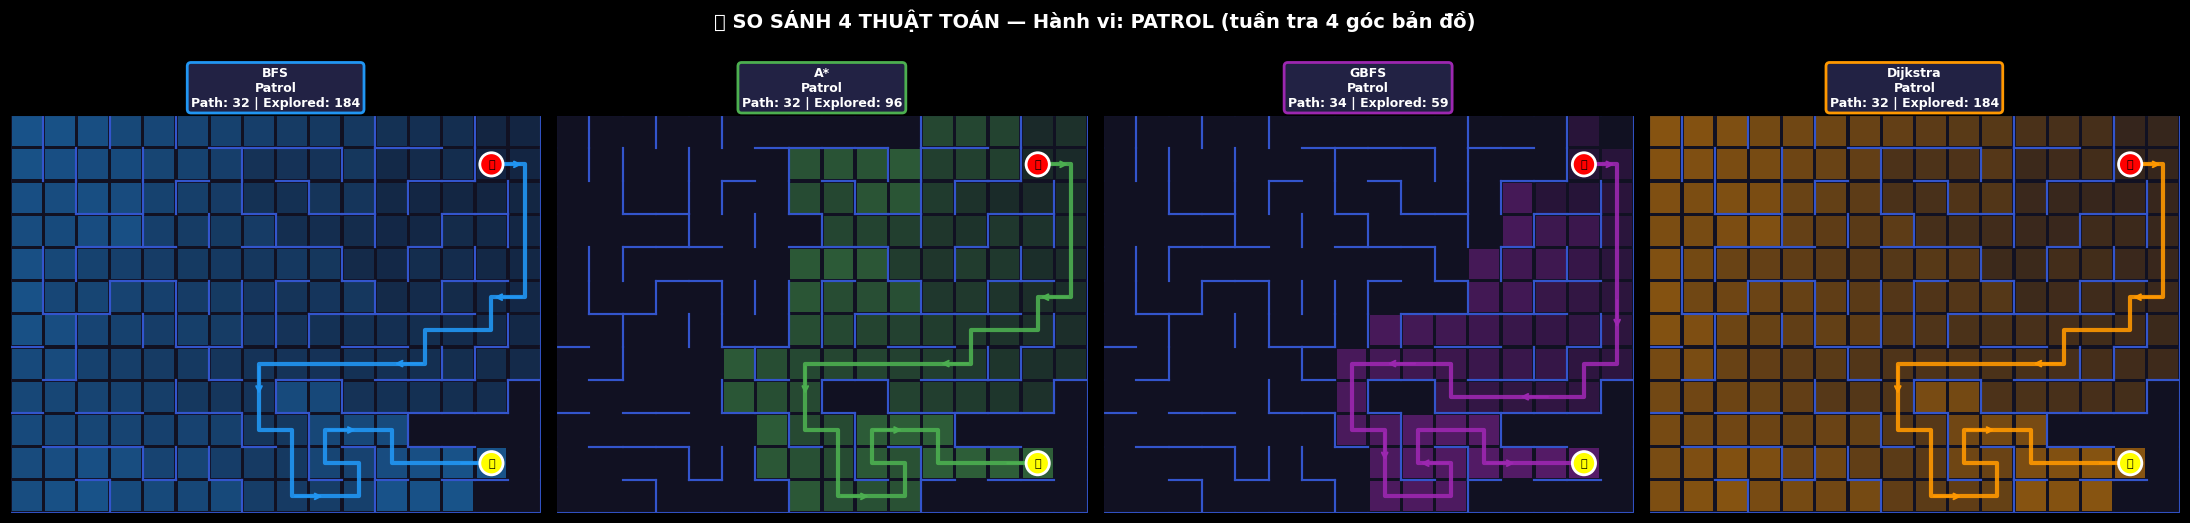


📊 Target (🟡) là 1 trong 4 góc — Ghost không truy đuổi mà tuần tra ổn định


In [52]:
fig, axes = plt.subplots(1, 4, figsize=(22, 5.5), facecolor="#000000")
fig.suptitle("🚨 SO SÁNH 4 THUẬT TOÁN — Hành vi: PATROL (tuần tra 4 góc bản đồ)",
             fontsize=14, fontweight="bold", color="white", y=1.02)

for ax, (algo_name, algo_func) in zip(axes, ALGORITHMS.items()):
    target = get_behavior_target("patrol", ghost_pos, pacman_pos, pacman_dir, COLS, ROWS)
    path, explored = algo_func(grid, COLS, ROWS, ghost_pos, target)
    color = ALGO_COLORS[algo_name]
    draw_maze_sim(ax, grid, COLS, ROWS, explored, path, ghost_pos, target,
                  algo_name, "Patrol", color)

plt.tight_layout()
plt.show()
print("\n📊 Target (🟡) là 1 trong 4 góc — Ghost không truy đuổi mà tuần tra ổn định")

## 9. So sánh 4 thuật toán — Hành vi RANDOM

Mục tiêu (🟡) là **một ô bất kỳ** trên bản đồ. Ghost di chuyển không thể đoán trước.

## 9. So sánh 4 thuật toán — Hành vi RANDOM

Mục tiêu (🟡) là **một ô bất kỳ** trên bản đồ. Ghost di chuyển không thể đoán trước.

C:\Users\Admin\AppData\Local\Temp\ipykernel_6484\2319552404.py:14: UserWarning: Glyph 128123 (\N{GHOST}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\Admin\AppData\Local\Temp\ipykernel_6484\2319552404.py:14: UserWarning: Glyph 128993 (\N{LARGE YELLOW CIRCLE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\Admin\AppData\Local\Temp\ipykernel_6484\2319552404.py:14: UserWarning: Glyph 127922 (\N{GAME DIE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()


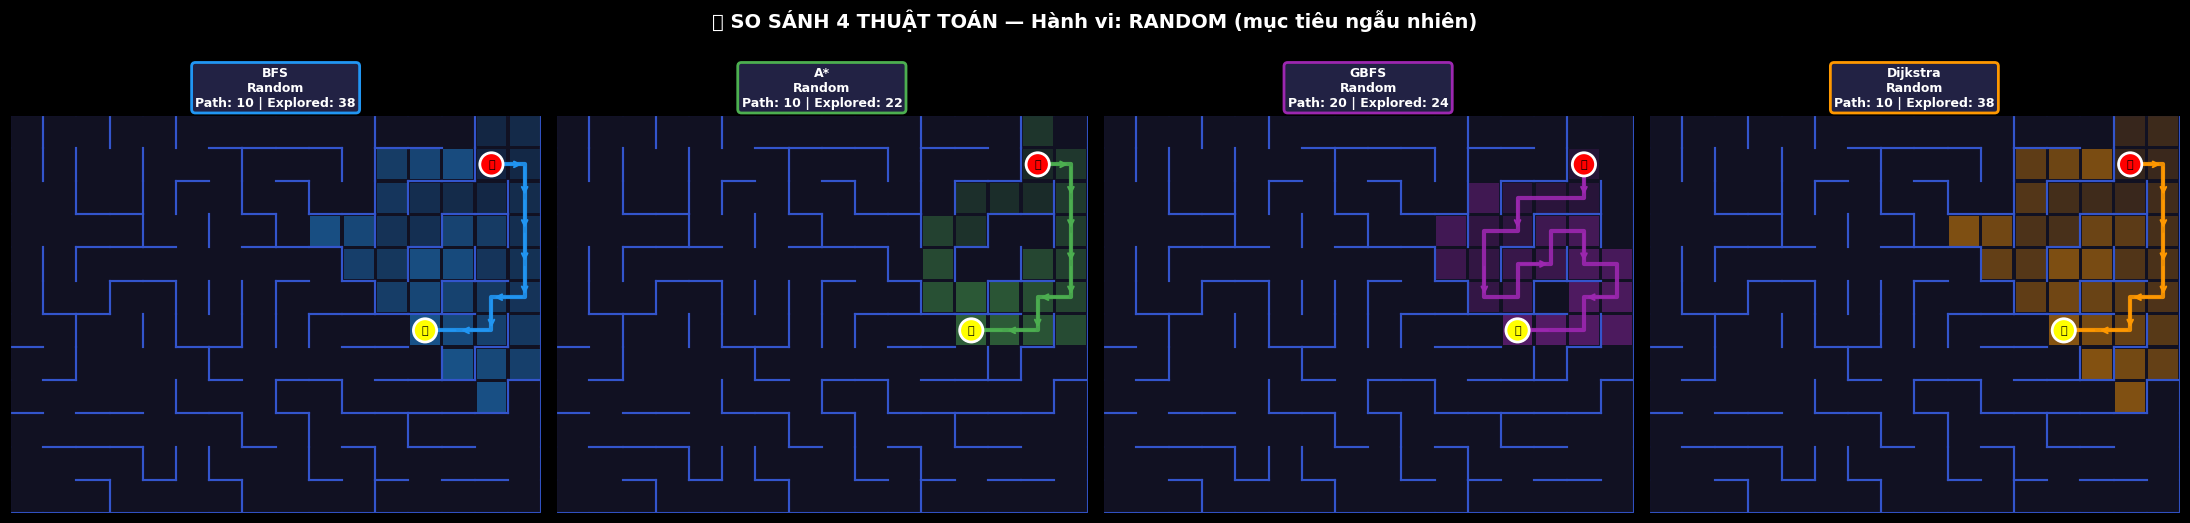


📊 Target (🟡) là ô ngẫu nhiên — cùng seed=99 để 4 thuật toán có cùng mục tiêu, dễ so sánh


In [53]:
fig, axes = plt.subplots(1, 4, figsize=(22, 5.5), facecolor="#000000")
fig.suptitle("🎲 SO SÁNH 4 THUẬT TOÁN — Hành vi: RANDOM (mục tiêu ngẫu nhiên)",
             fontsize=14, fontweight="bold", color="white", y=1.02)

# Cùng seed để 4 thuật toán có cùng mục tiêu ngẫu nhiên → công bằng so sánh
for ax, (algo_name, algo_func) in zip(axes, ALGORITHMS.items()):
    random.seed(99)  # reset seed cho mỗi thuật toán → cùng target
    target = get_behavior_target("random", ghost_pos, pacman_pos, pacman_dir, COLS, ROWS)
    path, explored = algo_func(grid, COLS, ROWS, ghost_pos, target)
    color = ALGO_COLORS[algo_name]
    draw_maze_sim(ax, grid, COLS, ROWS, explored, path, ghost_pos, target,
                  algo_name, "Random", color)

plt.tight_layout()
plt.show()
print("\n📊 Target (🟡) là ô ngẫu nhiên — cùng seed=99 để 4 thuật toán có cùng mục tiêu, dễ so sánh")

## 10. Kết luận

### Tóm tắt thuật toán trong dự án

| Thuật toán | Vai trò | Đặc điểm |
|:-----------|:-------:|:---------|
| **DFS** (Randomized) | 🏗️ Tạo mê cung | Recursive Backtracking — đảm bảo mọi ô đều liên thông |
| **BFS** | 🔍 Tìm đường | Duyệt theo chiều rộng — luôn ra đường ngắn nhất |
| **A\*** | 🔍 Tìm đường | g(n) + h(n) — **hiệu quả nhất**, ít explored nhờ heuristic |
| **GBFS** | 🔍 Tìm đường | Chỉ h(n) — nhanh nhất nhưng đường có thể vòng |
| **Dijkstra** | 🔍 Tìm đường | Chi phí tăng dần — như BFS với priority queue |

### Nhận xét theo hành vi

| Hành vi | Đặc trưng | Thuật toán phù hợp nhất |
|:--------|:----------|:-----------------------:|
| **Chase** | Đuổi thẳng — cần đường ngắn nhất | A\* (tối ưu + nhanh) |
| **Predict** | Chặn đầu — cần phản hồi nhanh | GBFS (ưu tiên tốc độ) |
| **Flank** | Đánh sau — cần đường ổn định | BFS / A\* |
| **Patrol** | Tuần tra cố định — không cần thông minh | Dijkstra / BFS |
| **Random** | Mục tiêu bất định — hiệu năng quan trọng | A\* (cân bằng tốt) |

### Kết hợp đề xuất cho 4 Ghost Pacman

| Ghost | Thuật toán | Hành vi | Lý do |
|:------|:-----------|:--------|:------|
| 🔴 **Blinky** | A\* | Chase | Đuổi tối ưu, luôn tìm đường ngắn nhất |
| 🩷 **Pinky** | GBFS | Predict | Phản hồi nhanh để chặn đầu Pacman |
| 🩵 **Inky** | BFS | Flank | Tìm đường ngắn nhất để đánh sau |
| 🟠 **Clyde** | Dijkstra | Patrol | Tuần tra ổn định các góc bản đồ |

### Quan sát chính

1. **Cùng một mê cung** (seed=42), khi đổi **thuật toán** → đường đi và số ô duyệt thay đổi rõ rệt.
2. Khi đổi **hành vi** → vị trí mục tiêu (🟡) thay đổi → cách Ghost di chuyển hoàn toàn khác.
3. **A\* duyệt ít ô nhất** trong các thuật toán tối ưu nhờ kết hợp chi phí thực và heuristic.
4. **GBFS nhanh nhất** nhưng đường đi không đảm bảo ngắn — dễ thấy ở hành vi Flank/Patrol khi mục tiêu xa.
5. **DFS không xuất hiện** trong tìm đường vì nó được dùng để **tạo mê cung** — DFS tìm đường thường cho ra đường rất dài, không phù hợp với Ghost AI.